# **2.2.1 텐서 다루기**
**텐서 생성 및 변환**


In [1]:
import torch
print(torch.tensor([[1,2], [3,4]]))
print(torch.tensor([[1,2],[3,4]], device = "cuda:0")) #GPU에 텐서 생성
print(torch.tensor([[1,2],[3,4]], dtype = torch.float64)) #dtype을 이용해 텐서 생성

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]], device='cuda:0')
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [2]:
#tensor를 ndarray로 변환
temp  = torch.tensor([[1,2],[3,4]])
print(temp.numpy())

temp = torch.tensor([[1,2], [3,4]], device = "cuda:0")
print(temp.to("cpu").numpy()) #GPU 상의 텐서를 CPU의 텐서로 변환 후 ndarray로 변환

[[1 2]
 [3 4]]
[[1 2]
 [3 4]]


**텐서의 인덱스 조작**
* torch.FloatTensor: 32비트의 부동소수점
* torch.DoubleTensor: 64 비트의 부동 소수점
* torch.LongTensor: 64 비트의 부호가 있는 정수

In [3]:
#텐서의 인덱스 조작
temp = torch.FloatTensor([1,2,3,4,5,6,7])
print(temp[0], temp[1], temp[-1])
print('----------------------')
print(temp[2:5], temp[4:-1])

tensor(1.) tensor(2.) tensor(7.)
----------------------
tensor([3., 4., 5.]) tensor([5., 6.])


**텐서 연산 및 차원 조작**
* 텐서 간의 타입이 다르면 연산이 불가

In [4]:
v = torch.tensor([1,2,3])
w = torch.tensor([3,4,6])
print(w - v)

tensor([2, 2, 3])


* 텐서의 차원을 변경하는 가장 대표적인 방법 : view를 이용
* 텐서를 결합하는 stack, cat
* 교환하는 t, transpose


view는 넘파이의 reshape과 유사/cat은 다른 길이의 텐서를 하나로 변합할 때 사용/ transepose는 행렬의 전치 외에도 차원의 순서를 변경할 때도 사용

In [5]:
temp = torch.tensor([[1,2], [3,4]])
print(temp.shape)
print('----------------------')
print(temp.view(4,1)) #2*2 행렬을 4*1로 변형
print('----------------------')
print(temp.view(-1)) #1차원 벡터로 변형
print('----------------------')
print(temp.view(1,-1)) #-1은 (1,?)와 같은 의미로 다른 차원으로부터 해당 값을 유추. (1,?) 형태로 만들어야하므로 (1,4)가 됨
print('----------------------')
print(temp.view(-1, 1)) # (?,1)의 의미로 (?,1)형태 만족해야하므로 (4,1)이 됨


torch.Size([2, 2])
----------------------
tensor([[1],
        [2],
        [3],
        [4]])
----------------------
tensor([1, 2, 3, 4])
----------------------
tensor([[1, 2, 3, 4]])
----------------------
tensor([[1],
        [2],
        [3],
        [4]])


# **2.2.2데이터 준비**
* Pandas 사용 or pyTorch 제공 데이터 이용
* 이미지 데이터 -> 데이터 읽고 전처리 후 배치 단위로 분할 처리
* 텍스트 데이터 -> 임베딩 과정 거쳐 서로 다른 길이의 시퀀스를 배치 단위로 분할 처리

**단순하게 파일 불러와서 사용**
* 판다스 라이브러리 통해 JSON, PDF, CSV 등 파일 불러옴

In [6]:
!pip install pandas



```
import pandas as pd
import torch
data = pd.read_csv('../class2.csv')

#csv 파일의 x 칼럼의 값을 넘파이 배열로 받아 Tensor(dtype)으로 바꾸어줌
x = torch.from_numpy(data['x'].values).unsqueeze(dim =1).float()
#csv 파일의 y 칼럼의 값을 넘파이 배열로 받아 Tensor(dtype)으로 바꾸어줌
y = torch.from_numpy(data['y'].values).unsqueeze(dim=1).float()
```



**커스텀 데이서셋을 만들어서 사용**
* 데이터를 조금씩 나눠서 불러서 사용하는 방식


```
class CustomDataset(torch.utils.data.Dataset):
  def __init__(self): #필요한 변수를 선언하고, 데이터셋의 전처리를 해주는 함수
  def __len__(self): #데이터셋의 길이. 즉, 샘플의 수를 가져오는 함수
  def __getitem__(self, index): #데이터셋에서 특정 데이터를 가져오는 함수(index번째 데이터 반환하는 함수. 반환하는 값은 텐서의 형태를 취함)
```



**예제**

```
import pandas as pd
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class CustomDataset(Dataset):
  def __init__(self, csv_file):
    self.label = pd.read_csv(csv_file)
  
  def __len__(self):
    return len(self.label)
  
  def __getitem__(self, idx):
    sample = torch.tensor(self.label.iloc[idx, 0:3]).int()
    label = torch.tensor(self.label.iloc[idx, 3]).int()
    return sample, label

tensor_dataset = CustomDataset('../covtype.csv')
dataset = DataLoader(tensor_dataset, batch_size=4, shuffle=True)
```



** torch.utils.data.DataLoader **


데이터로더 객체는 학습에 사용될 데이터 전체를 보관했다가 모델 학습을 할 때 배치 크기만큼 데이터를 꺼내서 사용.이때 주의할 것은 데이터를 미리 잘라 놓는 것이 아니라 내부적으로 반복자에 포함된 인덱스를 이용해 배치 크기만큼 반환
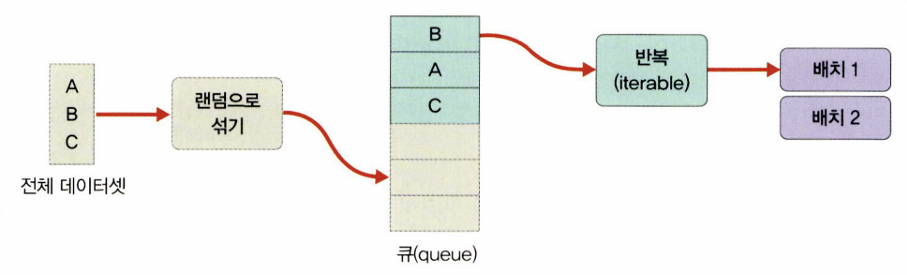


데이터 로더는 다음과 같이 for 문을 이용해 구문을 반복 실행하는 것과 같음


```
for i, data in enumerate(dataset, 0):
  print(i, end = '')
  batch = data[0]
  print(batch.size())
```
* 출력 결과


```
0torch.Size([4,3])
1torch.Size([4,3])
2torch.Size([4,3])
3torch.Size([4,3])
4torch.Size([4,3])
```




**파이토치에서 제공하는 데이터셋 사용**
* torchvision 은 파이토치에서 제공하는 데이터셋 모음 패키지
* request 라이브러리 설치 필요
* request는 HTTP 요청에 대한 처리를 위해 사용

In [7]:
!pip install requests

In [8]:
import torchvision.transforms as transforms

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (1.0,))
]) #평균이 0.5, 표준편차가 1.0이 되도록 데이터의 분포를 조정

from torchvision.datasets import MNIST
import requests
download_root = '../chap02/data/MNIST_DATASET'

train_dataset = MNIST(download_root, transform = mnist_transform, train=True, download = True)
valid_dataset = MNIST(download_root, transform = mnist_transform, train= False, download = True)
test_dataset  = MNIST(download_root, transform = mnist_transform, train= False, download = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 45.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.59MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.95MB/s]


# **2.2.3 모델 정의**
* 모델을 정의하기 위해서 모듈을 상속한 클래스 사용

* **계층**: 모듈 또는 모듈을 구성하는 한 개의 계층으로 합성곱층, 선형 계층 등이 존재
* **모듈**: 한 개 이상의 계층이 모여서 구성된 것으로, 모듈이 모여 새로운 모듈을 만들 수 있음
* **모델**: 최종적으로 원하는 네트워크로, 한개의 모듈이 모델이 될 수 있음

**단순 신경망을 정의하는 방법**
* nn.Module을 상속받지 않는 매우 단순한 모델을 만들 때 사용



```
model = nn.Linear(in_features = 1, out_features=1, bias=True)
```

**nn.Module()을 상속해 정의하는 방법**
* nn.Module을 상속받는 모델은 기본적으로 __init__()과 forward() 함수를 포함
* forward()에서는 모델에서 실핻돼야할 연산 정의



```
class MLP(Module):
  def __init__(self, inputs):
    super(MLP, self).__init__()
    self.layer = Linear(inputs, 1) #계층 정의
    self.activation = Sigmoid() #활성화함수 정의
  
  def forward(self, X):
    X = self.layer(X)
    X = self.activation(X)
    return X
```

**Sequential 신경망을 정의하는 방법**




In [9]:
import torch.nn as nn
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels = 64, kernel_size = 5),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(2)
    )

    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels = 630, kernel_size = 5),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(2)
    )
    self.layer3 = nn.Sequential(
        nn.Linear(in_features = 30*5*5, out_features = 10, bias = True),
        nn.ReLU(inplace = True),
    )

    def forward(self, x):
      x = self.layer1(x)
      x = self.layer2(x)
      x = x.view(x.shape[0], -1)
      x = self.layer3(x)
      return x
model = MLP()

print("Printing children\n--------------------------")
print(list(model.children()))
print("\n\nPrinting Modules\n-----------------------")
print(list(model.modules()))

Printing children
--------------------------
[Sequential(
  (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Conv2d(64, 630, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Linear(in_features=750, out_features=10, bias=True)
  (1): ReLU(inplace=True)
)]


Printing Modules
-----------------------
[MLP(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 630, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Linear(in_feat

**model.moduels() & model.children()**
* model.modules() : 모델의 네트워크에 대한 모든 노드를 반환
* model.children() :  같은 수준의 하위 노드를 반환
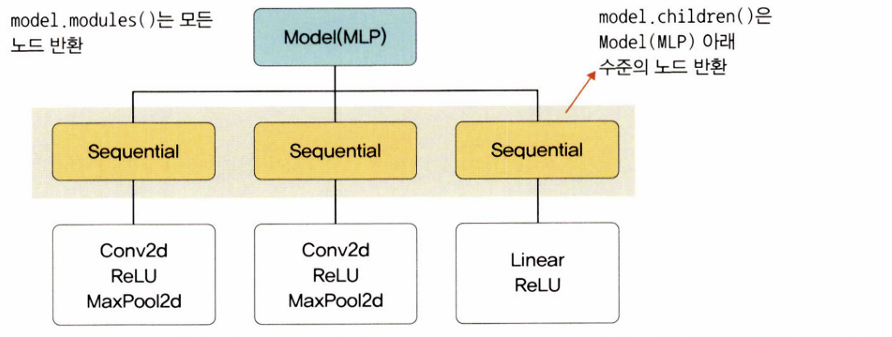

**함수로 신경망을 정의하는 방법**
* sequential을 이용하는 것과 동일하지만, 함수로 선언할 경우 변수에 저장해 놓은 계층들을 재사용할 수 있음.
* 모델이 복잡해지는 단점도 있음
* 복잡한 모델의 경우, 함수를 이용하는 것보다 nn.Module()을 상속받아 사용하는 것이 편리



```
def MLP(in_features = 1, hidden_features =20, out_features =1):
  hidden = nn.Linear(in_features = in_features, out_features=hidden_features, bias=True)
  activation = nn.ReLU()
  output = nn.Linear(in_features = hidden_features, out_features = out_features, bias = True)
  net = nn.Sequential(hidden, activation, output)
  return net
```



# **2.2.4 모델의 파라미터 정의**

* 모델의 파라미터르 정의하는 예시 코드


```
from torch.optim import optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, momentum = 0.9)
scheduler = torch.optim.lr_scheduler.LambdaLr(optimizer = optimizer, lr_lambda = lambda epoch:0.95 ** epoch)

for epoch in range(1, 100+1): #epoch 수만큼 데이터 반복해 처리
  for x,y in dataloader:
    optimizer.zero_grad()

loss_fn(model(x), y).backward()
optimizer.step()
scheduler.step()
```



# **2.2.6 모델 평가**
* 함수와 모듈을 이용하는 방법으로 평가


In [10]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.9 MB/s eta 0:00:00


**함수를 이용해  모델을 평가하는 코드**


```
import torch
import torchmetrics

preds = torch.randn(10,5).softmax(dim=-1)
target = torch.randint(5,(10,))

acc = torchmetrics.functional.accuracy(preds, target)
```



**모듈을 이용해 모델을 평가하는 코드**


```
import torch
import torchmetrics

metric = torchmetrics.Accuracy() #모델 평가 초기화

n_batches = 10
for i in range(n_batches):
  preds = torch.randn(10,5).softmax(dim=-1)
  target = torch.randint(5,(10,))

  acc = metric(preds, target)
  print(F"Accuracy on batch {i} :{acc}") #현재 배치에서 모델 평가

acc = metric.compute()
print(f"Accuracy on all datat: {acc}") #모든 배치에서 모델 평가
```



# **2.2.7 훈련 과정 모니터링**
* 텐서보드를 이용하면 학습에 사용되는 각종 파라미터 값이 어떻게 변화하는지 손쉽게 시각화 가능

**텐서보드 사용법**
1. 텐서보드 설정
2. 텐서보드에 기록
3. 텐서보드를 사용해 모델 구조 살핌



In [12]:
!pip install tensorboard



```
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("../chap02/tensorboard")  #모니터링에 필요한 값들이 저장될 위치

for epoch in range(num_epochs):
  model.train() #학습 모드로 전환(dropout=True)
  batch_loss = 0.0

  for i, (x,y) in eumerate(dataloader):
    x,y = x.to(device).float(), y.to(device).float()
    outputs = model(x)
    loss = criterion(outputs, y)
    writer.add_scaler("Loss", loss, epoch) #스칼라 값을 기록
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

writer.close()
```



In [15]:
!tensorboard --logdir ../chap02/tensorboard --port 6006

/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:292: SyntaxWarning: invalid escape sequence '\s'
  "[`\000-\040\177-\240\s]+",
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:339: SyntaxWarning: invalid escape sequence '\s'
  style = re.compile('url\s*\(\s*[^\s)]+?\s*\)\s*').sub(' ', style)
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:354: SyntaxWarning: invalid escape sequence '\s'
  if not re.match("^\s*([-\w]+\s*:[^:;]*(;\s*|$))*$", style):
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:358: SyntaxWarning: invalid escape sequence '\w'
  for prop, value in re.findall('([-\w]+)\s*:\s*([^:;]*)', style):
2026-03-08 06:53:36.211939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772952816.236595    8278 cuda_dnn.

**model.train()&model.eval()**
* model.train() : 훈련 데이터셋에 사용하며 모델 훈련이 진행될 것임을 알림. dropout 이 활성화됨
* model.eval(): 모델을 평가할 때는 모든 노드를 사용하겠다는 의미로 검증과 테스트 데이터셋에 사용

**model.eval() 사용**


```
model.eval() #검증 모드로 전환(dropout=False)
with torch.no_grad():
  valid_loss = 0

  for x,y in valid_dataloader:
    outputs = model(x)
    loss = F.cross_entropy(outputs, y.long().squeeze())
    valid_loss += float(loss)
    y_hat += [outputs[

valid_loss = valid_loss/len(valid_loader)
```

* with torch.no_grad()를 사용하는 이유


: 파이토치는 모든 연산과 기울기 값을 저장. 하지만 검증 과정에서는 역전파가 필요하지 않기 때문에 사용해서 기울기 값을 저장하지 않도록 함.

# **2.4 파이토치 코드 맛보기**

ouput인 차상태를 예측하는 코드 작성


In [17]:
#필요한 라이브러리 호출
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [18]:
#데이터 호출
dataset = pd.read_csv('/content/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


* 단어를 벡터로 바꾸어주는 **임베딩**처리가 필요

<Axes: ylabel='count'>

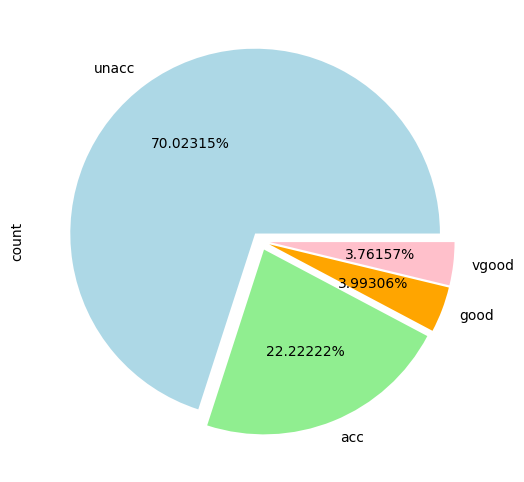

In [20]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind = 'pie', autopct = "%0.005f%%", colors = ['lightblue', 'lightgreen', 'orange', 'pink'], explode = (0.05, 0.05, 0.05, 0.05))

딥러닝은 통계 알고리즘을 기반으로 하기 때문에 단어를 숫자(텐서)로 변환.
**데이터 전처리**
1. 데이터 파악
* 예제 데이터릐 칼럼들은 모두 범주형 데이터
* astype() 메서드를 이용해 범주 특성을 갖는 범주형 타입으로 변환 -> 텐서로 변환

범주형 데이터 ->dataset[category] -> Numpy array-> Tensor

In [22]:
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
  dataset[category] = dataset[category].astype('category')

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

범주형 데이터를 숫자로 변환하기 위해 cat.codes 사용
* 다만, 어떤 클래스가 어떤 숫자로 매핑돼 있는지 확인 어려운 단점 존재

**np.stack과 np.concatenate**
* 넘파이 객체를 합칠 때 사용하는 메서드
* 차원의 유지 여부에 대한 차이 존재
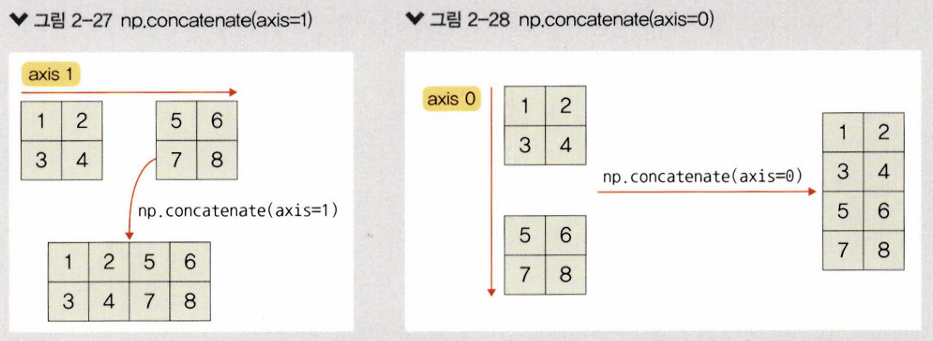

* np.concatenate : 같이 선택한 축을 기준으로 두 개의 배열을 연결
* np.stack: 배열들을 새로운 축으로 합쳐 줌. 반드시 두 배열의 차원이 동일해야함.
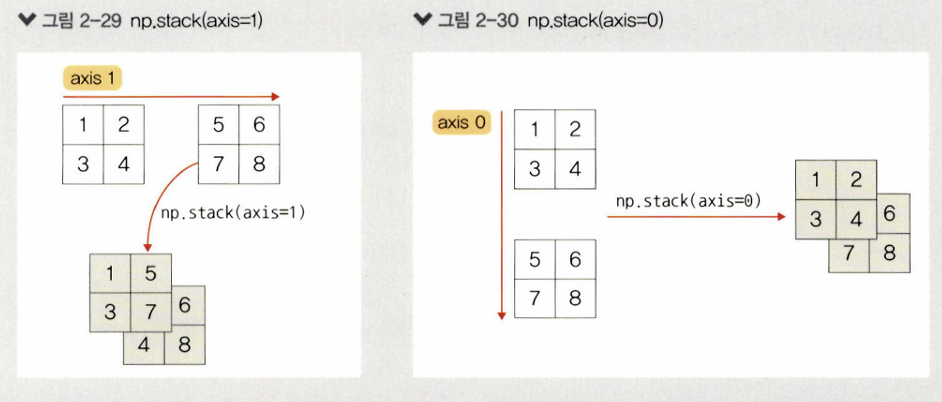

In [23]:
a = np.array([[1,2], [3,4]])
b = np.array([[5,6], [7,8]])
c = np.array([[5,6],[7,8], [9,10]])

print(np.concatenate((a,b), axis = 0))
print('-----------------------')
print(np.stack((a,b), axis = 0))

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
-----------------------
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]


In [24]:
print(np.concatenate((a,c), axis = 0))
print(np.stack((a,c), axis = 0))


[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]]


ValueError: all input arrays must have the same shape

=>np.stack은 합치려는 두 넘파이 배열의 차원이 다르기에 오류 발생

In [26]:
#배열을 텐서로 변환
categorical_data = torch.tensor(categorical_data, dtype = torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [27]:
#레이블로 사용할 칼럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output) #get_dummies는 가변수(문자->숫자)를 만드는 함수
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


In [28]:
import pandas as pd
import numpy as np

data = {
    'gender' : ['male', 'female', 'male'],
    'weight' : [72,55,68],
    'nation' : ['Japan', 'Korea', 'Australia']
}
df = pd.DataFrame(data)
df

,gender,weight,nation
0,male,72,Japan
1,female,55,Korea
2,male,68,Australia


In [29]:
pd.get_dummies(df)

,weight,gender_female,gender_male,nation_Australia,nation_Japan,nation_Korea
0,72,False,True,False,True,False
1,55,True,False,False,False,True
2,68,False,True,True,False,False


**ravel(), reshape(), flatten()**
* 텐서의 차원을 바꿀 때 사용






In [30]:
a = np.array([[1,2],[3,4]])
print(a.ravel())
print(a.reshape(-1))
print(a.flatten())

[1 2 3 4]
[1 2 3 4]
[1 2 3 4]


In [31]:
torch.Size([1728,6])
torch.Size([6912])

torch.Size([6912])

**워드 임베딩**: 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법
* 높은 차원의 임베딩일수록 단어 간의 세부적인 관계 잘 파악 가능
* 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경
-> 임베딩 크기 정의: (칼럼의 고윳값 수 )/2

In [33]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [34]:
#데이터셋 분리
total_records = 1728
test_records = int(total_records * .2) #전체 데이터 중 20%를 테스트 용도로 사용

categorical_train_data = categorical_data[:total_records -test_records]
categorical_test_data = categorical_data[total_records - test_records: total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [35]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))


1383
1383
345
345


In [36]:
#모델의 네트워크 생성
class Model(nn.Module):
  def __init__(self, embedding_size, output_size, layers, p = 0.4):
    super().__init__()
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])

    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols
    for i in layers:
      all_layers.append(nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True))
      all_layers.append(nn.BatchNorm1d(i))
      all_layers.append(nn.Dropout(p))
      input_size = i
    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn.Sequential(*all_layers)

  def forward(self, x_categorical):
    embeddings = []
    for i,e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))
    x = torch.cat(embeddings, 1)
    x = self.embedding_dropout(x)
    x= self.layers(x)
    return x

=> 코드에 대한 설명
1. 클래스 형태로 구현되는 모델은 nn.Module 상속받음
2. __init() 파라미터:
* self == 자기자신
* embedding_size == 범주형 칼럼의 임베딩 크기
* output_size == 출력층의 크기 *
layers == 모든 계층에 대한 목록
* p == 드롭아웃(기본값= 0.5)
3. super().__init__()은 부모 클래스에 접근할 때 사용.self  사용X
4. 모델의 네크워크 계층 구축.
* Linear : 선형 계층은 입력 데이터에 선형 변환을 진행한 결과. y = Wx + b
* ReLU
* BatchNorm1d: 배치 정규화 용도
* Dropout : 과적합 방지에 사용

5. forward() 함수는 학습 데이터를 입력 받아서 연산 진행

In [37]:
# Model 클래스의 객체 생성
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p = 0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [40]:
#손실 함수와 옵티마이저에 대해 정의
#손실함수 :cross entropy
#optimizer : Adam
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [45]:
#CPU, GPU 사용 지정
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [46]:
#모델 학습
epochs = 500
aggregated_losses = []

# 모델을 device로 옮기기
model.to(device)

# train_outputs를 device로 옮기기 (이미 되어 있지만 명확성을 위해 유지)
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
  i +=1
  # categorical_train_data를 device로 옮기기
  y_pred = model(categorical_train_data.to(device))
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25==1:
    print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')
  optimizer.zero_grad()
  single_loss.backward()
  optimizer.step()

print(f'epoch: {i:3} loss:{single_loss.item():10.10f}')

epoch:   1 loss: 1.57576644
epoch:  26 loss: 1.36175740
epoch:  51 loss: 1.27364290
epoch:  76 loss: 1.16205990
epoch: 101 loss: 1.06984782
epoch: 126 loss: 0.93620133
epoch: 151 loss: 0.81122071
epoch: 176 loss: 0.74775022
epoch: 201 loss: 0.70066720
epoch: 226 loss: 0.64715916
epoch: 251 loss: 0.63038146
epoch: 276 loss: 0.61643034
epoch: 301 loss: 0.59595400
epoch: 326 loss: 0.59686154
epoch: 351 loss: 0.59423023
epoch: 376 loss: 0.58233428
epoch: 401 loss: 0.58552837
epoch: 426 loss: 0.58544266
epoch: 451 loss: 0.56781894
epoch: 476 loss: 0.57124269
epoch: 500 loss:0.5734619498


In [57]:
#test dataset으로 모델 예측
test_outputs = test_outputs.to(device = device, dtype = torch.int64)
with torch.no_grad():
  # categorical_test_data를 device로 옮기기
  y_val = model(categorical_test_data.to(device))
  loss = loss_function(y_val, test_outputs)
print(f'Loss: :{loss: .8f}')

Loss: : 0.56536323


In [58]:
print(y_val[:5])

tensor([[ 2.6046,  1.5073, -3.5692, -3.6814],
        [ 2.0693,  1.0108, -2.8165, -2.6836],
        [ 3.5124,  2.3579, -4.5941, -4.6506],
        [ 2.0631,  1.0066, -3.1885, -3.1054],
        [ 2.7731,  1.3833, -4.2668, -4.1896]], device='cuda:0')


In [59]:
#가장 큰 값을 갖는 인덱스 확인
y_val = np.argmax(y_val.cpu(), axis = 1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [60]:
#정확도 확인
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs.cpu(), y_val))
print(classification_report(test_outputs.cpu(), y_val))
print(accuracy_score(test_outputs.cpu(), y_val))

[[258   1]
 [ 85   1]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.50      0.01      0.02        86

    accuracy                           0.75       345
   macro avg       0.63      0.50      0.44       345
weighted avg       0.69      0.75      0.65       345

0.7507246376811594
